In [19]:
!pip install statsforecast

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast, models
import plotly.graph_objects as go

In [21]:
df = pd.read_csv('top_lvl_combined_f.csv').drop(columns=['Unnamed: 0'])
df['date'] = pd.to_datetime(df['date'])
df.head()

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
0,OZON,2023-01-31,Ozon fresh,7.267095e+08,1018707.0,10909.0,3270.0,525.0,1692.0
1,OZON,2023-02-28,Ozon fresh,1.535720e+09,1342474.0,2439.0,2318.0,326.0,399.0
2,OZON,2023-03-31,Ozon fresh,1.917223e+09,1884459.0,11701.0,3570.0,494.0,1660.0
3,OZON,2023-04-30,Ozon fresh,3.227949e+09,3666176.0,15484.0,4720.0,741.0,2047.0
4,OZON,2023-05-31,Ozon fresh,4.234719e+09,4125418.0,25133.0,7917.0,1375.0,2924.0


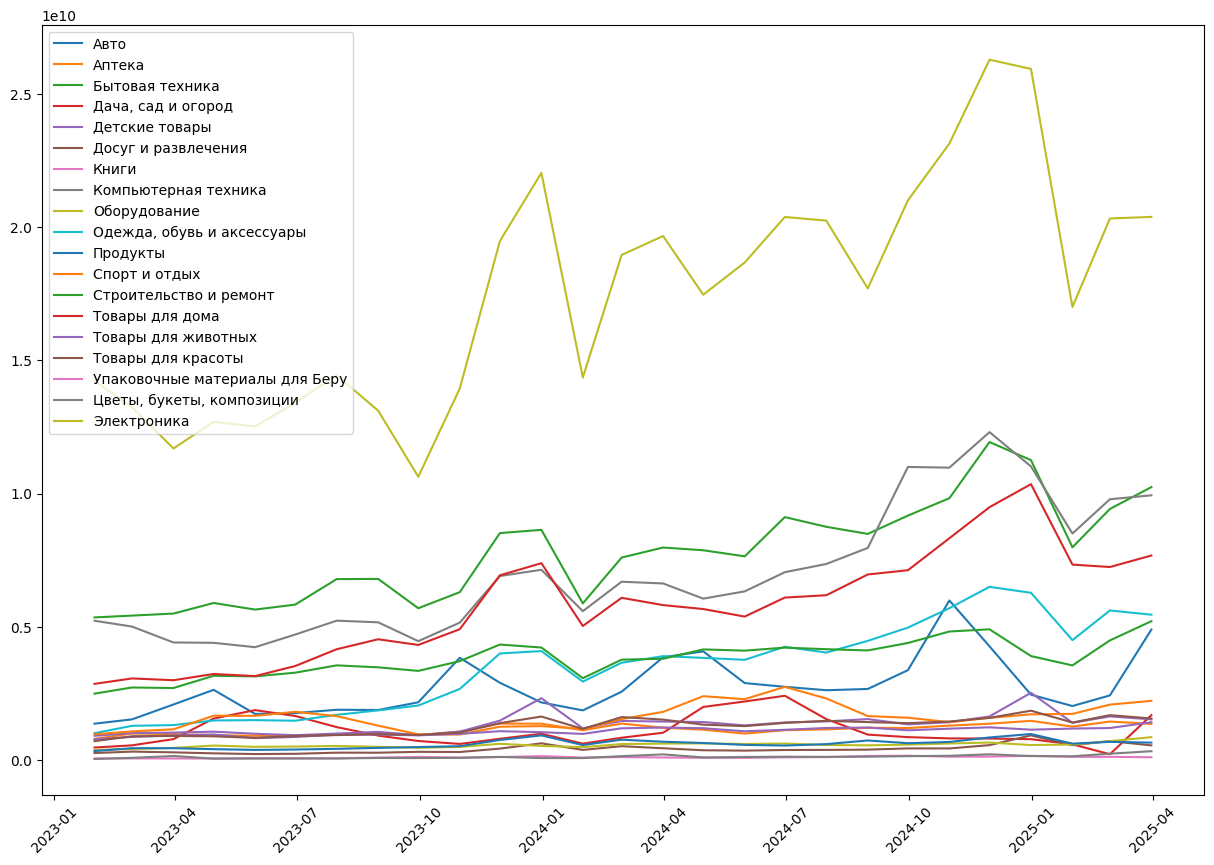

In [22]:
df_ya = df.loc[df['marketplace'] == 'Яндекс.Маркет']
fig = plt.figure(figsize=(15, 10))
for cat in df_ya['category'].unique():
    plt.plot(df_ya.loc[df_ya['category'] == cat, 'date'], df_ya.loc[df_ya['category'] == cat, 'revenue_rub'], label=cat)
    plt.xticks(rotation=45)
plt.legend()

In [23]:
df.loc[df['marketplace'] == 'OZON'].iloc[301]

,301
marketplace,OZON
date,2025-03-31 00:00:00
category,Дом и сад
revenue_rub,2962392871919.0
sales,5707214789.0
goods,27355835.0
goods with sales,848272.0
sellers,186771.0
brands,70750.0


In [24]:
iqr = df['revenue_rub'].quantile(0.75) - df['revenue_rub'].quantile(0.25)
low = df['revenue_rub'].quantile(0.25) - 1.5 * iqr
high = df['revenue_rub'].quantile(0.75) + 1.5 * iqr

iqr_s = df['sales'].quantile(0.75) - df['sales'].quantile(0.25)
low_s = df['sales'].quantile(0.25) - 1.5 * iqr_s
high_s = df['sales'].quantile(0.75) + 1.5 * iqr_s
usl = (df['revenue_rub'] < low) & (df['revenue_rub'] > high) & (df['sales'] < low_s) & (df['sales'] > high_s)

In [25]:
df_ozon = df[df['marketplace'] == 'OZON']

In [26]:
# Выбираем уникальные категории
categories = df_ozon['category'].unique()

# Выбираем категории без символа '�' — это "правильные" категории
valid_categories = set(cat for cat in categories if '�' not in cat)

# "Сломанные" категории содержат '�'
broken_categories = [cat for cat in categories if '�' in cat]

import difflib

# Словарь: "сломанная" категория -> "исправленная"
category_mapping = {}

for broken_cat in broken_categories:
    # Находим наиболее похожую правильную категорию
    matches = difflib.get_close_matches(broken_cat, valid_categories, n=1, cutoff=0.5)
    if matches:
        category_mapping[broken_cat] = matches[0]

# Заменяем с помощью map с аргументом category_mapping
df_ozon_fixed = df_ozon.copy()

df_ozon_fixed['category'] = df_ozon['category'].replace(category_mapping)

In [27]:
df[df['marketplace'] == 'OZON'] = df_ozon_fixed

In [28]:
df.loc[(df['marketplace'] == 'OZON') & (df['date'] == '2023-11-30'), 'revenue_rub'] /= 10

In [29]:
dict_revenue_keys = {}
id = 0

for m, c in zip(df['marketplace'], df['category']):
    key = f'{m}/{c}'
    if key not in dict_revenue_keys:
        dict_revenue_keys[key] = id
        id += 1

In [30]:
dict_revenue = {}
ids = []
values = []
dates = []

for mp, cat, value, date in zip(df['marketplace'], df['category'], df['revenue_rub'], df['date']):
    ids.append(dict_revenue_keys[f'{mp}/{cat}'])
    values.append(value)
    dates.append(date)

dict_revenue['id'] = ids
dict_revenue['value'] = values
dict_revenue['date'] = dates

In [31]:
ts_revenue = pd.DataFrame(dict_revenue)

In [32]:
ind_bad = ts_revenue['id'].value_counts()[ts_revenue['id'].value_counts() < 5].index
ts_revenue = ts_revenue[~ts_revenue['id'].isin(ind_bad)].sort_values(by=['id', 'date']).reset_index(drop=True)

In [33]:
treshold = ts_revenue['date'].sort_values(ascending=True)[round(27 * 0.7)]
df_train = ts_revenue[ts_revenue['date'] < treshold]
df_test = ts_revenue[ts_revenue['date'] >= treshold]

In [34]:
train_stats = (
    df_train.groupby('id')['value']
    .agg(n='size', n_unique='nunique')
)

good_ids = train_stats[
    (train_stats['n'] >= 10) &
    (train_stats['n_unique'] > 1)
].index

df_train = df_train[
    df_train['id'].isin(good_ids)
].copy()

df_test = df_test[
    df_test['id'].isin(good_ids)
].copy()

In [35]:
df_train = df_train.rename(columns={
    'id': 'unique_id',
    'value': 'y',
    'date': 'ds',
})

df_test = df_test.rename(columns={
    'id': 'unique_id',
    'value': 'y',
    'date': 'ds',
})

HORIZON = 8

models_baseline = StatsForecast(
    models=[
        models.Naive(),
        models.AutoARIMA(seasonal=False),
        models.AutoETS(),
        models.AutoTheta(),
    ],
    freq='ME',
    n_jobs=-1,
    verbose=True,
)

df_pred = models_baseline.forecast(df=df_train, h=HORIZON)

Forecast:   0%|          | 0/69 [Elapsed: 00:00]

In [36]:
key_id = 35
ts_15_train = df_train[df_train['unique_id'] == key_id].reset_index(drop=True)
ts_15_test = df_test[df_test['unique_id'] == key_id].reset_index(drop=True)

In [37]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=ts_15_train["ds"], y=ts_15_train["y"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=ts_15_test["ds"], y=ts_15_test["y"], name="Test", line=dict(color="red"))
)
fig.add_trace(
    go.Scatter(
        x=ts_15_test["ds"], y=df_pred[df_pred['unique_id']==key_id]['Naive'], name="Naive", line=dict(color="green")
    )
)

fig.add_trace(
    go.Scatter(
        x=ts_15_test["ds"], y=df_pred[df_pred['unique_id']==key_id]['AutoARIMA'], name="AutoARIMA", line=dict(color="purple")
    )
)
fig.add_trace(
    go.Scatter(
        x=ts_15_test["ds"], y=df_pred[df_pred['unique_id']==key_id]['AutoETS'], name="AutoETS", line=dict(color="pink")
    )
)
fig.add_trace(
    go.Scatter(
        x=ts_15_test["ds"], y=df_pred[df_pred['unique_id']==key_id]['AutoTheta'], name="AutoTheta", line=dict(color="brown")
    )
)

fig.update_layout(
    title="Train/Test Split with Predictions", xaxis_title="Date", yaxis_title="Value"
)
fig.show()

In [38]:
dict_revenue_keys

{'OZON/Ozon fresh': 0,
 'OZON/Автомобили': 1,
 'OZON/Автотовары': 2,
 'OZON/Аксессуары': 3,
 'OZON/Антиквариат и коллекционирование': 4,
 'OZON/Аптека': 5,
 'OZON/Билеты, отели, туры': 6,
 'OZON/Бытовая техника': 7,
 'OZON/Бытовая химия и гигиена': 8,
 'OZON/Детские товары': 9,
 'OZON/Дом и сад': 10,
 'OZON/Игры и консоли': 11,
 'OZON/Канцелярские товары': 12,
 'OZON/Книги': 13,
 'OZON/Красота и здоровье': 14,
 'OZON/Мебель': 15,
 'OZON/Музыка и видео': 16,
 'OZON/Обувь': 17,
 'OZON/Одежда': 18,
 'OZON/Продукты питания': 19,
 'OZON/Спорт и отдых': 20,
 'OZON/Строительство и ремонт': 21,
 'OZON/Товары для взрослых': 22,
 'OZON/Товары для животных': 23,
 'OZON/Товары для курения и аксессуары': 24,
 'OZON/Туризм, рыбалка, охота': 25,
 'OZON/Хобби и творчество': 26,
 'OZON/Цифровые товары': 27,
 'OZON/Электроника': 28,
 'OZON/Электронные сигареты и товары для курения': 29,
 'OZON/Ювелирные украшения': 30,
 'Wildberries/Автотовары': 31,
 'Wildberries/Аксессуары': 32,
 'Wildberries/Бытовая т